# LLM Judge Cho Explanation

Đánh giá `explanation` bằng GPT-4o mini.

## 1. Setup

In [10]:
# %pip install -q openai python-dotenv pandas tqdm pydantic

In [11]:
from __future__ import annotations

import asyncio
import json
import math
import os
import re
from pathlib import Path
from typing import Any, Literal

import pandas as pd
from dotenv import load_dotenv
from openai import AsyncOpenAI
from pydantic import BaseModel, ConfigDict, Field
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "judge":
    PROJECT_ROOT = PROJECT_ROOT.parent

load_dotenv(PROJECT_ROOT / ".env")

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
EVALUATOR_MODEL_ID = "openai/gpt-4o-mini"
EVALUATOR_ALIAS = "gpt4o_mini"

client = AsyncOpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)

if not OPENROUTER_API_KEY:
    print("Chưa thấy OPENROUTER_API_KEY trong .env. Cell gọi API sẽ lỗi nếu chưa cấu hình key.")
else:
    print("Đã nạp OPENROUTER_API_KEY.")
print(f"Evaluator model: {EVALUATOR_MODEL_ID}")

Đã nạp OPENROUTER_API_KEY.
Evaluator model: openai/gpt-4o-mini


## 2. Load Data

In [12]:
EXPERIMENT_ID = "gemini-2.5-flash__semantic__clip_finetuned__reranker_1"
JUDGE_MODEL_ALIAS = "gemini-2.5-flash"

JUDGE_OUTPUT_CSV = PROJECT_ROOT / "judge" / "judge_outputs_openrouter" / f"factchecking_final_results_{JUDGE_MODEL_ALIAS}__{EXPERIMENT_ID}__full.csv"
GOLD_CSV = PROJECT_ROOT / "FinalDataset" / "claims_merged.csv"
OUTPUT_DIR = PROJECT_ROOT / "judge" / "judge_outputs_openrouter"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_TEST = False
SMOKE_ROWS = 20
OUTPUT_SUFFIX = "smoke" if SMOKE_TEST else "full"

EXPLANATION_JUDGE_CSV = OUTPUT_DIR / f"explanation_llm_judge_{EVALUATOR_ALIAS}__{JUDGE_MODEL_ALIAS}__{EXPERIMENT_ID}__{OUTPUT_SUFFIX}.csv"
EXPLANATION_METRICS_CSV = OUTPUT_DIR / f"explanation_llm_judge_metrics_{EVALUATOR_ALIAS}__{JUDGE_MODEL_ALIAS}__{EXPERIMENT_ID}__{OUTPUT_SUFFIX}.csv"

print(f"Judge output: {JUDGE_OUTPUT_CSV.exists()} - {JUDGE_OUTPUT_CSV}")
print(f"Gold dataset: {GOLD_CSV.exists()} - {GOLD_CSV}")
print(f"Smoke test: {SMOKE_TEST}, rows: {SMOKE_ROWS}")
print(f"Output: {EXPLANATION_JUDGE_CSV}")

Judge output: True - d:\FactCheckPipeline\judge\judge_outputs_openrouter\factchecking_final_results_gemini-2.5-flash__gemini-2.5-flash__semantic__clip_finetuned__reranker_1__full.csv
Gold dataset: True - d:\FactCheckPipeline\FinalDataset\claims_merged.csv
Smoke test: False, rows: 20
Output: d:\FactCheckPipeline\judge\judge_outputs_openrouter\explanation_llm_judge_gpt4o_mini__gemini-2.5-flash__gemini-2.5-flash__semantic__clip_finetuned__reranker_1__full.csv


In [13]:
df_judge = pd.read_csv(JUDGE_OUTPUT_CSV)
df_gold = pd.read_csv(GOLD_CSV)[["id", "claim", "label", "reason"]].copy()

if "final_error" in df_judge.columns:
    df_judge = df_judge[df_judge["final_error"].fillna("").astype(str).str.strip() == ""].copy()

df_judge = df_judge.drop_duplicates(subset=["claim_id"], keep="last")

df_eval_input = df_gold.merge(df_judge, left_on="id", right_on="claim_id", how="inner", suffixes=("_gold", "_pred"))
df_eval_input = df_eval_input[
    df_eval_input["explanation"].fillna("").astype(str).str.strip().ne("")
    & df_eval_input["reason"].fillna("").astype(str).str.strip().ne("")
].copy()

if SMOKE_TEST:
    df_eval_input = df_eval_input.head(SMOKE_ROWS).copy()

print(f"Số dòng dùng để đánh giá explanation: {len(df_eval_input)}")
df_eval_input[["id", "claim", "label", "verdict", "explanation", "reason"]].head()

Số dòng dùng để đánh giá explanation: 1293


,id,claim,label,verdict,explanation,reason
0,1,Công an tỉnh Thái Bình đã khởi tố 10 đối tượng trong đường dây lừa đảo hỗ trợ vay vốn online.,supported,REFUTED,"Công an tỉnh Bình Dương đang điều tra vụ án, không phải Công an tỉnh Thái Bình. Số lượng đối tượng được đề cập trong bằng chứng là 4, không phải 10.","Claim này được đánh giá là supported vì văn bản chính xác khẳng định việc Công an tỉnh Thái Bình đã khởi tố 10 đối tượng trong đường dây lừa đảo, và hình ảnh cũng minh họa nhóm..."
1,2,Các đối tượng cầm đầu đường dây lừa đảo đã thuê nhà tại Hà Nội và TP. Hồ Chí Minh để thực hiện hành vi phạm tội.,supported,NEI,"Bằng chứng xác nhận đường dây lừa đảo đã thuê văn phòng ở Hà Nội để thực hiện hành vi phạm tội, nhưng không có thông tin về việc thuê nhà tại TP. Hồ Chí Minh.","Claim này được đánh giá là supported vì văn bản đã nêu rõ việc các đối tượng cầm đầu có nguồn gốc từ Hà Nội và TP. Hồ Chí Minh, và đã thuê nhà tại hai thành phố này để thực hiệ..."
2,3,Thượng úy Nguyễn Đức Phước là Điều tra viên thụ lý chính của vụ án lừa đảo này.,refuted,REFUTED,Thượng úy Nguyễn Đức Phước không phải là điều tra viên thụ lý chính của vụ án lừa đảo này. Điều tra viên thụ lý chính là Thượng úy Nguyễn Văn Thái.,"Claim này bị đánh giá là refuted vì văn bản cung cấp thông tin rõ ràng rằng Thượng úy Nguyễn Văn Thái là Điều tra viên thụ lý chính, còn Đại úy Nguyễn Đức Phước là Phó Đội trưở..."
3,4,Tổng số tiền bị chiếm đoạt bởi đường dây lừa đảo này ước tính là 100 tỷ đồng.,nei,REFUTED,"Các nguồn tin cho thấy số tiền bị chiếm đoạt bởi đường dây lừa đảo này là khoảng 21 tỷ đồng hoặc hơn 160 tỷ đồng, không phải 100 tỷ đồng như tuyên bố.","Claim này được đánh giá là nei vì văn bản chỉ nêu số tiền thiệt hại ""lên đến hàng chục triệu đồng mỗi trường hợp"" nhưng không cung cấp tổng số tiền bị chiếm đoạt. Hình ảnh và c..."
4,5,Các đối tượng lừa đảo đã bị bắt giữ vào ngày 15 tháng 5 năm 2024.,nei,REFUTED,"Thông tin cho biết các đối tượng lừa đảo bị bắt giữ vào khoảng thời gian từ ngày 26 tháng 2 năm 2025 đến ngày 3 tháng 3 năm 2025, không phải ngày 15 tháng 5 năm 2024.","Claim này được đánh giá là nei vì văn bản và hình ảnh đều không cung cấp thông tin về ngày bắt giữ cụ thể của các đối tượng. Do đó, không đủ cơ sở để xác minh tính chính xác củ..."


## 3. Schema

In [14]:
PassLabel = Literal["pass", "borderline", "fail"]


class ExplanationJudgeResult(BaseModel):
    model_config = ConfigDict(extra="forbid")

    factual_consistency: int = Field(ge=1, le=5)
    verdict_alignment: int = Field(ge=1, le=5)
    completeness: int = Field(ge=1, le=5)
    vietnamese_clarity: int = Field(ge=1, le=5)
    no_hallucination: int = Field(ge=1, le=5)
    overall_score: float = Field(ge=1, le=5)
    pass_label: PassLabel
    judge_feedback: str


EXPLANATION_JUDGE_SCHEMA = ExplanationJudgeResult.model_json_schema()


SYSTEM_PROMPT = """You are an impartial evaluator for Vietnamese fact-checking explanations.
Evaluate the generated explanation against the claim, gold label, model verdict, and gold reason.

Score each criterion from 1 to 5:
- factual_consistency: matches facts in the gold reason and does not contradict the claim context.
- verdict_alignment: explanation supports the model verdict logically.
- completeness: covers the central reason why the claim is supported, refuted, or not enough information.
- vietnamese_clarity: clear, natural Vietnamese, concise and understandable.
- no_hallucination: does not add unsupported entities, numbers, dates, locations, or causes.

Pass label rules:
- pass: overall_score >= 4.0 and no criterion below 3.
- borderline: overall_score >= 3.0 but not pass.
- fail: overall_score < 3.0 or severe factual contradiction.

Return JSON only following the schema exactly.
"""


def extract_json(text):
    text = (text or "").strip()
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.IGNORECASE | re.DOTALL).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if not match:
            raise
        return json.loads(match.group(0))


def validate_result(raw_text):
    return ExplanationJudgeResult.model_validate(extract_json(raw_text)).model_dump()

## 4. Run Judge

In [15]:
RUN_LLM_JUDGE = True 
MAX_CONCURRENT_REQUESTS = 3 if SMOKE_TEST else 8
SAVE_EVERY = 1 if SMOKE_TEST else 25
RETRY_LIMIT = 3
MAX_TEXT_CHARS = 2500


def clip_text(value, max_chars=MAX_TEXT_CHARS):
    text = str(value or "").strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(" ", 1)[0] + "..."


def load_successful_rows(output_csv):
    if not output_csv.exists():
        return [], set()
    existing = pd.read_csv(output_csv)
    if "judge_error" in existing.columns:
        existing = existing[existing["judge_error"].fillna("").astype(str).str.strip() == ""].copy()
    completed = set(existing["claim_id"].astype(str)) if "claim_id" in existing.columns else set()
    return existing.to_dict("records"), completed


def write_rows(rows, output_csv):
    pd.DataFrame(rows).to_csv(output_csv, index=False, encoding="utf-8-sig")


async def call_explanation_judge(messages, retry_note=""):
    if retry_note:
        messages = [
            *messages,
            {"role": "user", "content": f"Output trước đó lỗi validation: {retry_note}. Hãy trả lại JSON hợp lệ, không markdown."},
        ]
    response = await client.chat.completions.create(
        model=EVALUATOR_MODEL_ID,
        messages=messages,
        temperature=0.0,
        max_tokens=1200,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "explanation_quality_judge",
                "strict": True,
                "schema": EXPLANATION_JUDGE_SCHEMA,
            },
        },
    )
    return response.choices[0].message.content or ""


async def judge_one_explanation(row, semaphore):
    async with semaphore:
        user_prompt = f"""[CLAIM]
{clip_text(row['claim'])}

[GOLD LABEL]
{row['label']}

[MODEL VERDICT]
{row['verdict']}

[GOLD REASON]
{clip_text(row['reason'])}

[GENERATED EXPLANATION]
{clip_text(row['explanation'])}
"""
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ]

        retry_note = ""
        last_error = ""
        for attempt in range(1, RETRY_LIMIT + 1):
            try:
                raw = await call_explanation_judge(messages, retry_note=retry_note)
                result = validate_result(raw)
                return {
                    "claim_id": row["id"],
                    "gold_label": row["label"],
                    "verdict": row["verdict"],
                    "generated_explanation": row["explanation"],
                    "gold_reason": row["reason"],
                    **result,
                    "judge_error": "",
                }
            except Exception as e:
                last_error = str(e)
                retry_note = last_error[:1000]
                await asyncio.sleep(min(2 * attempt, 8))

        return {
            "claim_id": row["id"],
            "gold_label": row["label"],
            "verdict": row["verdict"],
            "generated_explanation": row["explanation"],
            "gold_reason": row["reason"],
            "factual_consistency": math.nan,
            "verdict_alignment": math.nan,
            "completeness": math.nan,
            "vietnamese_clarity": math.nan,
            "no_hallucination": math.nan,
            "overall_score": math.nan,
            "pass_label": "fail",
            "judge_feedback": "",
            "judge_error": last_error,
        }


async def run_llm_judge():
    rows, completed_ids = load_successful_rows(EXPLANATION_JUDGE_CSV)
    todo = df_eval_input[~df_eval_input["id"].astype(str).isin(completed_ids)].copy()

    print(f"Đã có kết quả thành công: {len(completed_ids)}")
    print(f"Còn cần đánh giá: {len(todo)}")

    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    tasks = [asyncio.create_task(judge_one_explanation(row, semaphore)) for _, row in todo.iterrows()]

    completed_since_save = 0
    for task in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="explanation-judge"):
        rows.append(await task)
        completed_since_save += 1
        if completed_since_save >= SAVE_EVERY:
            write_rows(rows, EXPLANATION_JUDGE_CSV)
            completed_since_save = 0

    write_rows(rows, EXPLANATION_JUDGE_CSV)
    print(f"Đã lưu: {EXPLANATION_JUDGE_CSV}")
    return pd.DataFrame(rows)


if RUN_LLM_JUDGE:
    df_expl_judge = await run_llm_judge()
else:
    print("RUN_LLM_JUDGE = False, bỏ qua gọi API.")

Đã có kết quả thành công: 0
Còn cần đánh giá: 1293


explanation-judge:   0%|          | 0/1293 [00:00<?, ?it/s]

Đã lưu: d:\FactCheckPipeline\judge\judge_outputs_openrouter\explanation_llm_judge_gpt4o_mini__gemini-2.5-flash__gemini-2.5-flash__semantic__clip_finetuned__reranker_1__full.csv


## 5. Metrics

In [16]:
if EXPLANATION_JUDGE_CSV.exists():
    df_expl_judge = pd.read_csv(EXPLANATION_JUDGE_CSV)
    print(f"Đã nạp {len(df_expl_judge)} dòng từ {EXPLANATION_JUDGE_CSV}")
else:
    df_expl_judge = pd.DataFrame()
    print(f"Chưa có output: {EXPLANATION_JUDGE_CSV}")

df_expl_judge.head()

Đã nạp 1293 dòng từ d:\FactCheckPipeline\judge\judge_outputs_openrouter\explanation_llm_judge_gpt4o_mini__gemini-2.5-flash__gemini-2.5-flash__semantic__clip_finetuned__reranker_1__full.csv


,claim_id,gold_label,verdict,generated_explanation,gold_reason,factual_consistency,verdict_alignment,completeness,vietnamese_clarity,no_hallucination,overall_score,pass_label,judge_feedback,judge_error
0,3,refuted,REFUTED,Thượng úy Nguyễn Đức Phước không phải là điều tra viên thụ lý chính của vụ án lừa đảo này. Điều tra viên thụ lý chính là Thượng úy Nguyễn Văn Thái.,"Claim này bị đánh giá là refuted vì văn bản cung cấp thông tin rõ ràng rằng Thượng úy Nguyễn Văn Thái là Điều tra viên thụ lý chính, còn Đại úy Nguyễn Đức Phước là Phó Đội trưở...",5,5,4,5,5,4.8,pass,"Giải thích chính xác và rõ ràng, phù hợp với lý do vàng. Tuy nhiên, có thể bổ sung thêm thông tin về vai trò của Đại úy Nguyễn Đức Phước để hoàn thiện hơn.",NaN
1,6,nei,REFUTED,"Đường dây lừa đảo này đã chiếm đoạt tiền của hơn 200 bị hại trên cả nước, không chỉ riêng tại tỉnh Thái Bình.",Claim này được đánh giá là NOT_ENOUGH_INFO vì bài viết không cung cấp thông tin xác nhận rằng đường dây lừa đảo chỉ nhắm đến nạn nhân tại Thái Bình. Việc Công an tỉnh Thái Bình...,5,5,5,5,5,5.0,pass,"Giải thích hoàn toàn nhất quán với lý do vàng, hỗ trợ cho phán quyết của mô hình và cung cấp thông tin đầy đủ về phạm vi hoạt động của đường dây lừa đảo. Ngôn ngữ rõ ràng và tự...",NaN
2,2,supported,NEI,"Bằng chứng xác nhận đường dây lừa đảo đã thuê văn phòng ở Hà Nội để thực hiện hành vi phạm tội, nhưng không có thông tin về việc thuê nhà tại TP. Hồ Chí Minh.","Claim này được đánh giá là supported vì văn bản đã nêu rõ việc các đối tượng cầm đầu có nguồn gốc từ Hà Nội và TP. Hồ Chí Minh, và đã thuê nhà tại hai thành phố này để thực hiệ...",3,2,3,4,4,3.2,borderline,"Giải thích có một số thông tin chính xác nhưng không hoàn toàn phù hợp với lý do vàng. Nó chỉ đề cập đến Hà Nội mà không nhắc đến TP. Hồ Chí Minh, dẫn đến sự không nhất quán vớ...",NaN
3,4,nei,REFUTED,"Các nguồn tin cho thấy số tiền bị chiếm đoạt bởi đường dây lừa đảo này là khoảng 21 tỷ đồng hoặc hơn 160 tỷ đồng, không phải 100 tỷ đồng như tuyên bố.","Claim này được đánh giá là nei vì văn bản chỉ nêu số tiền thiệt hại ""lên đến hàng chục triệu đồng mỗi trường hợp"" nhưng không cung cấp tổng số tiền bị chiếm đoạt. Hình ảnh và c...",2,2,2,4,2,2.0,fail,"Giải thích không nhất quán với lý do vàng, vì nó đưa ra các con số không được hỗ trợ và mâu thuẫn với thông tin rằng không có tổng số tiền bị chiếm đoạt được xác minh. Điều này...",NaN
4,9,refuted,REFUTED,"Có 8 đối tượng bị Phòng Cảnh sát hình sự Công an tỉnh Thanh Hóa tạm giữ hình sự, trong đó có Bùi Quốc Ý, chứ không phải chỉ 5 đối tượng như tuyên bố.","Claim này bị đánh giá là refuted vì văn bản và hình ảnh đều cho thấy có tổng cộng 8 đối tượng bị tạm giữ hình sự trong vụ án, chứ không phải chỉ 5 đối tượng như tuyên bố.",5,5,5,5,5,5.0,pass,"Giải thích hoàn toàn nhất quán với lý do vàng, hỗ trợ cho phán quyết của mô hình và rõ ràng, dễ hiểu.",NaN


In [17]:
SCORE_COLS = [
    "factual_consistency",
    "verdict_alignment",
    "completeness",
    "vietnamese_clarity",
    "no_hallucination",
    "overall_score",
]

if df_expl_judge.empty:
    df_expl_metrics = pd.DataFrame()
    print("Chưa có kết quả LLM-as-a-judge để tính metrics.")
else:
    ok = df_expl_judge[df_expl_judge["judge_error"].fillna("").astype(str).str.strip() == ""].copy()
    metric_rows = []
    metric_rows.append({"metric": "num_rows", "value": len(ok)})
    metric_rows.append({"metric": "pass_rate", "value": (ok["pass_label"] == "pass").mean() if len(ok) else 0.0})
    metric_rows.append({"metric": "borderline_rate", "value": (ok["pass_label"] == "borderline").mean() if len(ok) else 0.0})
    metric_rows.append({"metric": "fail_rate", "value": (ok["pass_label"] == "fail").mean() if len(ok) else 0.0})
    for col in SCORE_COLS:
        metric_rows.append({"metric": f"mean_{col}", "value": ok[col].mean()})
        metric_rows.append({"metric": f"median_{col}", "value": ok[col].median()})

    df_expl_metrics = pd.DataFrame(metric_rows)
    display(df_expl_metrics)
    display(ok.groupby("pass_label").size().rename("count").reset_index())
    display(ok.groupby(["gold_label", "verdict"])[SCORE_COLS].mean().reset_index())

,metric,value
0,num_rows,1293.000000
1,pass_rate,0.837587
2,borderline_rate,0.050271
3,fail_rate,0.112142
4,mean_factual_consistency,4.395205
5,median_factual_consistency,5.000000
6,mean_verdict_alignment,4.525135
7,median_verdict_alignment,5.000000
8,mean_completeness,3.993039
9,median_completeness,4.000000


,pass_label,count
0,borderline,65
1,fail,145
2,pass,1083


,gold_label,verdict,factual_consistency,verdict_alignment,completeness,vietnamese_clarity,no_hallucination,overall_score
0,nei,NEI,4.687023,4.958015,4.003817,4.938931,4.954198,4.708397
1,nei,REFUTED,3.557692,4.128205,3.551282,4.615385,4.057692,3.914167
2,nei,SUPPORTED,1.666667,1.500000,1.833333,4.000000,2.583333,2.000000
3,refuted,NEI,2.696970,2.666667,2.363636,4.181818,4.818182,3.133333
4,refuted,REFUTED,4.866667,4.971795,4.538462,4.964103,4.933333,4.853846
5,refuted,SUPPORTED,2.000000,1.125000,2.000000,4.250000,3.500000,2.300000
6,supported,NEI,2.131579,1.684211,1.894737,4.000000,4.842105,2.531579
7,supported,REFUTED,1.829787,1.191489,2.148936,4.042553,4.106383,2.476596
8,supported,SUPPORTED,4.927954,4.997118,4.325648,4.991354,4.933718,4.835159


## 6. Save

In [18]:
if not df_expl_judge.empty:
    df_expl_metrics.to_csv(EXPLANATION_METRICS_CSV, index=False, encoding="utf-8-sig")
    print(f"Đã lưu metrics: {EXPLANATION_METRICS_CSV}")

    cols = [
        "claim_id",
        "gold_label",
        "verdict",
        "overall_score",
        "pass_label",
        "judge_feedback",
        "generated_explanation",
        "gold_reason",
        "judge_error",
    ]
    cols = [c for c in cols if c in df_expl_judge.columns]
    display(df_expl_judge.sort_values(["overall_score", "claim_id"], na_position="first")[cols].head(20))
else:
    print("Chưa có kết quả để lưu hoặc xem lỗi.")

Đã lưu metrics: d:\FactCheckPipeline\judge\judge_outputs_openrouter\explanation_llm_judge_metrics_gpt4o_mini__gemini-2.5-flash__gemini-2.5-flash__semantic__clip_finetuned__reranker_1__full.csv


,claim_id,gold_label,verdict,overall_score,pass_label,judge_feedback,generated_explanation,gold_reason,judge_error
18,19,supported,REFUTED,1.0,fail,"Giải thích không chính xác về người đưa ra yêu cầu, dẫn đến mâu thuẫn với thông tin trong yêu cầu. Điều này làm cho giải thích không thể hỗ trợ cho phán quyết của mô hình và kh...","Phó Thủ tướng đưa ra yêu cầu này là Nguyễn Hòa Bình, không phải Hồ Quốc Dũng như thông tin đã nêu.","Claim này được đánh giá là supported vì văn bản trực tiếp trích dẫn lời yêu cầu của Phó Thủ tướng về việc hành động nhanh nhất để cứu dân, và hình ảnh minh họa rõ ràng hành độn...",NaN
21,23,nei,REFUTED,1.0,fail,"Giải thích không nhất quán với sự thật trong lý do vàng, vì nó đưa ra số liệu cụ thể không được hỗ trợ và mâu thuẫn với nội dung của tuyên bố. Nó cũng không hỗ trợ cho phán quy...","Chính phủ đã cung cấp 1.759,875 tấn gạo cho Đắk Lắk, không phải 200 tấn. Bộ Nông nghiệp và Môi trường đã hỗ trợ 1.500 thùng mì tôm, không phải 500 thùng từ Chính phủ.","Claim này được đánh giá là nei vì văn bản chỉ đề cập chung chung về việc cung cấp gạo cứu đói mà không đưa ra số lượng cụ thể, loại hàng hóa khác hay địa điểm nhận cứu trợ như ...",NaN
38,36,nei,REFUTED,1.0,fail,"Giải thích chứa thông tin sai lệch nghiêm trọng về danh tính và giới tính của bệnh nhân, không phù hợp với lý do vàng. Nó cũng không hỗ trợ cho phán quyết của mô hình.","Thông tin bệnh nhân là nam giới 61 tuổi tên Nguyễn Văn Thị, bị suy thận độ 4 và được hỗ trợ tại Bệnh viện đa khoa tỉnh Bắc Ninh số 1, mâu thuẫn trực tiếp với tuyên bố.","Claim này được đánh giá là nei vì văn bản không chứa bất kỳ thông tin cụ thể nào về danh tính, tuổi tác hay giới tính của bệnh nhân gãy xương đùi, và không có nguồn bên ngoài n...",NaN
150,151,supported,REFUTED,1.0,fail,"Giải thích không nhất quán với sự thật trong lý do vàng, vì nó mâu thuẫn với thông tin về việc chị T. đã mất tiền và phương thức lừa đảo. Ngoài ra, giải thích cũng thêm thông t...","Chị T. chưa bị mất tiền và phương thức lừa đảo không phải là giả danh nhân viên giao hàng, mà là giả danh lính Mỹ và nhân viên sân bay.","Claim này được đánh giá là supported vì văn bản mô tả cụ thể trường hợp của chị T., số tiền bị mất và cách thức chị bị lừa bởi đối tượng giả danh nhân viên giao hàng.",NaN
164,160,refuted,SUPPORTED,1.0,fail,"Giải thích không chính xác và mâu thuẫn với lý do vàng. Nó khẳng định rằng Nguyễn Viết L đã bị khởi tố hình sự, trong khi lý do vàng chỉ ra rằng vụ việc vẫn đang trong giai đoạ...","Nguyễn Viết Linh đã bị Phòng Cảnh sát hình sự, Công an tỉnh Hà Tĩnh khởi tố hình sự, phù hợp với thông tin bạn đưa ra.","Claim này bị đánh giá là refuted vì văn bản chỉ ra rằng vụ việc đang trong giai đoạn 'củng cố hồ sơ để xử lý', điều này không đồng nghĩa với việc Nguyễn Viết L đã bị khởi tố hì...",NaN
208,209,nei,REFUTED,1.0,fail,"Giải thích không nhất quán với thông tin trong lý do vàng, vì nó đưa ra con số 216 tỷ đồng mà không có bằng chứng hỗ trợ, đồng thời mâu thuẫn với việc không có thông tin cụ thể...","Đường dây lừa đảo do Lê Khắc Ngọ cầm đầu có tồn tại và hoạt động trên không gian mạng, nhưng số tiền chiếm đoạt là 216 tỷ đồng, không phải 50 tỷ đồng.","Claim này được đánh giá là nei vì văn bản không cung cấp thông tin về tổng số tiền bị chiếm đoạt bởi đường dây lừa đảo của Lê Khắc Ngọ, hình ảnh cũng không hiển thị thông tin n...",NaN
224,227,nei,SUPPORTED,1.0,fail,Giải thích không nhất quán với lý do vàng vì nó khẳng định thông tin về ngày có hiệu lực của luật mà không có nguồn đáng tin cậy nào xác nhận. Điều này dẫn đến sự mâu thuẫn với...,"Luật Trật tự, an toàn giao thông đường bộ số 36/2024/QH15, bao gồm Khoản 5 Điều 27, sẽ có hiệu lực thi hành từ ngày 01 tháng 01 năm 2025.","Claim này được đánh giá là nei vì văn bản không cung cấp thông tin về ngày có hiệu lực của Luật Trật tự, an toàn giao thông đường bộ số 36/2024, và không có nguồn bên ngoài đán...",NaN
234,234,nei,REFUTED,1.0,fail,"Giải thích không nhất quán với lý do vàng, vì nó đưa ra mức phạt cụ thể mà không có trong văn bản

## 7. Plots

In [19]:

import matplotlib.pyplot as plt

if df_expl_judge.empty:
    print("Chưa có kết quả để plot.")
else:
    df_plot = df_expl_judge[df_expl_judge["judge_error"].fillna("").astype(str).str.strip() == ""].copy()
    print(f"Số dòng dùng để plot: {len(df_plot)}")


Số dòng dùng để plot: 1293


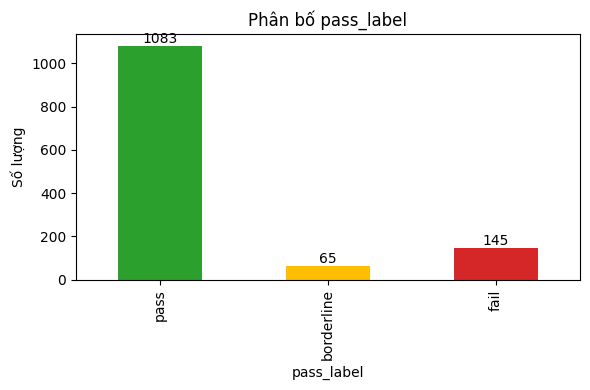

In [20]:

if not df_expl_judge.empty and not df_plot.empty:
    pass_counts = df_plot["pass_label"].value_counts().reindex(["pass", "borderline", "fail"]).fillna(0)

    ax = pass_counts.plot(kind="bar", figsize=(6, 4), color=["#2ca02c", "#ffbf00", "#d62728"])
    ax.set_title("Phân bố pass_label")
    ax.set_xlabel("pass_label")
    ax.set_ylabel("Số lượng")
    ax.bar_label(ax.containers[0])
    plt.tight_layout()
    plt.show()


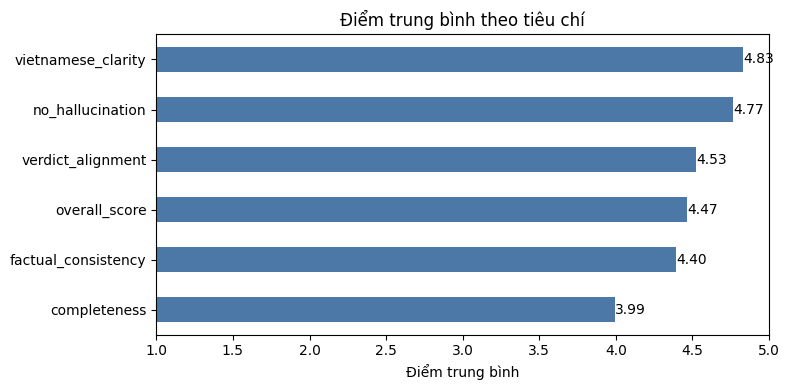

In [21]:

if not df_expl_judge.empty and not df_plot.empty:
    score_cols = [
        "factual_consistency",
        "verdict_alignment",
        "completeness",
        "vietnamese_clarity",
        "no_hallucination",
        "overall_score",
    ]
    mean_scores = df_plot[score_cols].mean().sort_values()

    ax = mean_scores.plot(kind="barh", figsize=(8, 4), color="#4c78a8")
    ax.set_title("Điểm trung bình theo tiêu chí")
    ax.set_xlabel("Điểm trung bình")
    ax.set_xlim(1, 5)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")
    plt.tight_layout()
    plt.show()


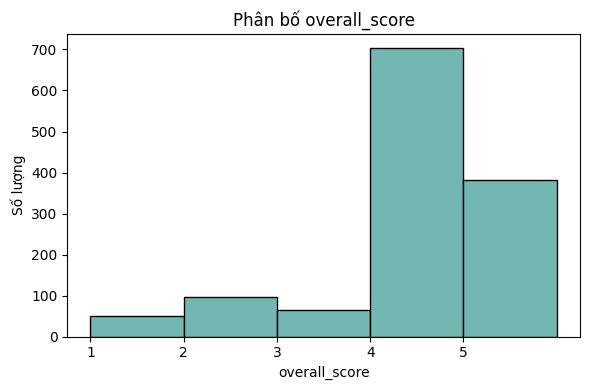

In [22]:

if not df_expl_judge.empty and not df_plot.empty:
    ax = df_plot["overall_score"].plot(kind="hist", bins=[1, 2, 3, 4, 5, 6], figsize=(6, 4), color="#72b7b2", edgecolor="black")
    ax.set_title("Phân bố overall_score")
    ax.set_xlabel("overall_score")
    ax.set_ylabel("Số lượng")
    ax.set_xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
    plt.show()


,verdict,count,mean,median
0,NEI,333,4.303904,4.8
1,REFUTED,593,4.418229,4.8
2,SUPPORTED,367,4.687193,4.8


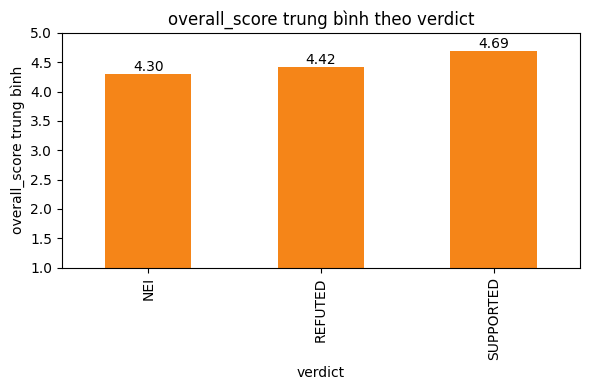

In [23]:

if not df_expl_judge.empty and not df_plot.empty:
    by_verdict = df_plot.groupby("verdict")["overall_score"].agg(["count", "mean", "median"]).reset_index()
    display(by_verdict)

    ax = by_verdict.set_index("verdict")["mean"].plot(kind="bar", figsize=(6, 4), color="#f58518")
    ax.set_title("overall_score trung bình theo verdict")
    ax.set_xlabel("verdict")
    ax.set_ylabel("overall_score trung bình")
    ax.set_ylim(1, 5)
    ax.bar_label(ax.containers[0], fmt="%.2f")
    plt.tight_layout()
    plt.show()


In [24]:

if not df_expl_judge.empty and not df_plot.empty:
    low_score_cols = [
        "claim_id",
        "gold_label",
        "verdict",
        "overall_score",
        "pass_label",
        "judge_feedback",
        "generated_explanation",
        "gold_reason",
    ]
    low_score_cols = [c for c in low_score_cols if c in df_plot.columns]
    display(df_plot.sort_values("overall_score")[low_score_cols].head(10))


,claim_id,gold_label,verdict,overall_score,pass_label,judge_feedback,generated_explanation,gold_reason
38,36,nei,REFUTED,1.0,fail,"Giải thích chứa thông tin sai lệch nghiêm trọng về danh tính và giới tính của bệnh nhân, không phù hợp với lý do vàng. Nó cũng không hỗ trợ cho phán quyết của mô hình.","Thông tin bệnh nhân là nam giới 61 tuổi tên Nguyễn Văn Thị, bị suy thận độ 4 và được hỗ trợ tại Bệnh viện đa khoa tỉnh Bắc Ninh số 1, mâu thuẫn trực tiếp với tuyên bố.","Claim này được đánh giá là nei vì văn bản không chứa bất kỳ thông tin cụ thể nào về danh tính, tuổi tác hay giới tính của bệnh nhân gãy xương đùi, và không có nguồn bên ngoài n..."
1217,1214,nei,SUPPORTED,1.0,fail,"Giải thích không nhất quán với sự thật trong lý do vàng, vì nó khẳng định thông tin không có trong văn bản và không có nguồn bên ngoài nào xác nhận. Điều này dẫn đến sự mâu thu...","Đại hội Thi đua yêu nước toàn quốc lần thứ XI sẽ được tổ chức tại Trung tâm Hội nghị Quốc gia ở Hà Nội, điều này được xác nhận bởi các nguồn tin.","Claim này được đánh giá là nei vì văn bản và hình ảnh đều không cung cấp bất kỳ thông tin nào về địa điểm tổ chức Đại hội, và không có nguồn bên ngoài nào trong ngữ cảnh bài vi..."
390,395,nei,REFUTED,1.0,fail,"Giải thích không nhất quán với sự thật trong lý do vàng, vì nó xác định sai tên và cấp bậc của nữ cán bộ công an. Nó cũng không hỗ trợ cho phán quyết của mô hình, dẫn đến việc ...","Nữ cán bộ công an trong hình ảnh được xác định là Đại úy Phan Thị Tâm, không phải Trần Thị Mai. Cô đang thực hiện nhiệm vụ tại Công an xã Kim Hoa.","Claim này được đánh giá là nei vì văn bản và hình ảnh đều không chứa thông tin chi tiết về tên hay cấp bậc của nữ cán bộ công an đang làm nhiệm vụ, và không có nguồn bên ngoài ..."
1090,1095,nei,SUPPORTED,1.0,fail,"Giải thích không nhất quán với thông tin trong lý do vàng, vì nó đưa ra thông tin không có thật về kết luận điều tra vào ngày 8 tháng 12 năm 2025, trong khi lý do vàng khẳng đị...","Cơ quan An ninh điều tra Bộ Công an đã ban hành Kết luận điều tra vào ngày 8 tháng 12 năm 2025, phù hợp với thông tin vụ án dự kiến kết thúc điều tra vào cuối năm 2025.","Claim này được đánh giá là nei vì văn bản không cung cấp bất kỳ thông tin nào về thời hạn hoặc dự kiến kết thúc điều tra vụ án, hình ảnh không có và không có nguồn bên ngoài nà..."
961,956,nei,REFUTED,1.0,fail,Giải thích không nhất quán với sự thật vì đưa ra số liệu mưa không đúng và không liên quan đến tuyên bố. Nó cũng không hỗ trợ cho phán quyết của mô hình và thiếu thông tin cần ...,"Thông tin cho biết tổng lượng mưa tại Huế trong 24 giờ qua là 1.085,8 mm, không phải 120 mm như tuyên bố. Ngoài ra, dữ liệu tham chiếu đến thời điểm khác.","Claim này được đánh giá là nei vì cả văn bản và hình ảnh đều không cung cấp bất kỳ thông tin nào về tổng lượng mưa đo được tại Thành phố Huế, và không có nguồn bên ngoài để xác..."
321,323,nei,REFUTED,1.0,fail,"Giải thích không nhất quán với thông tin trong lý do vàng, vì nó đưa ra con số cụ thể về số lượng nhà mà không có trong văn bản gốc. Điều này dẫn đến sự mâu thuẫn với tuyên bố ...","Chiến dịch Quang Trung đã hoàn thành 1.046 căn nhà, không phải khoảng 250 căn như tuyên bố. Ngoài ra, chiến dịch còn sửa chữa 34.759 căn nhà bị hư hỏng.",Claim này được đánh giá là nei vì văn bản không đề cập đến con số cụ thể về số lượng nhà được xây.
1036,1035,nei,REFUTED,1.0,fail,"Giải thích không nhất quán với sự thật trong lý do vàng, vì nó đưa ra thông tin sai về thời gian nhập ngũ của Thượng sĩ Nguyễn Ngọc Minh Nhật. Điều này dẫn đến sự không phù hợp...",Thông tin Thượng sĩ Nguyễn Ngọc Minh Nhật bắt đầu phục vụ trong lực lượng Công an từ năm 2020 là sai. Anh nhập ngành vào tháng 2/2024.,"Claim này được đánh giá là nei vì văn bản và hình ảnh đều không cung cấp thông tin về thời gian Thượng sĩ Nguyễn Ngọc Minh Nhật bắt đầu phục vụ trong lực lượng Công an, và khôn..."
1048,1052,nei,REFUTED,1.0,fail,Giải thích không nhất quán với sự thật vì đưa ra số liệu mưa không được xác nhận và không phù hợp với lý do vàng. Nó cũ